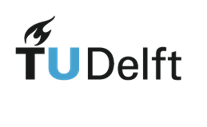




<div style="text-align: center">CIEM5110 – unit 3 – Measurement and Analysis of Vibrations<br>
    Assignment report : <b>Experimental modal analysis of a suspended beam</b></div>


<div style="text-align: center"><b>Deadline</b>: 11 April 2025, 23:59 hrs</div>

***

# Group # (fill in your group number)

**Names**

**Student numbers**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq

# Problem set 1: signal processing

### Exercise 1.1. Time domain signals
**a**. Plot the hammer force $F_2$ in the time domain and indicate two artefacts in the plot.

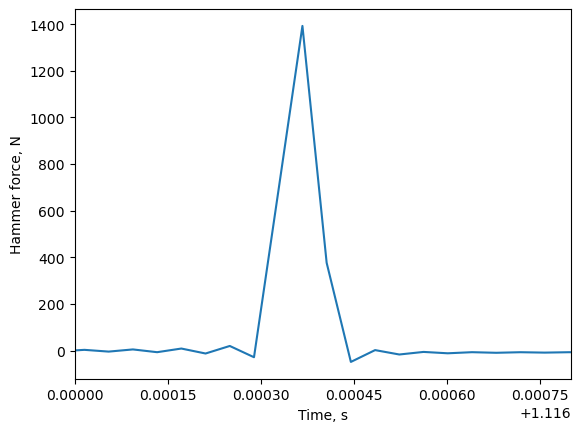

In [2]:
# import data form csv file
data_acc2T1 = pd.read_csv('data1/acc2T1.csv', skiprows=3).to_numpy()
data_acc2T2 = pd.read_csv('data1/acc2T2.csv', skiprows=3).to_numpy()
data_acc2T3 = pd.read_csv('data1/acc2T3.csv', skiprows=3).to_numpy()
data_acc2T4 = pd.read_csv('data1/acc2T4.csv', skiprows=3).to_numpy()
data_acc2T5 = pd.read_csv('data1/acc2T5.csv', skiprows=3).to_numpy()

t_F2 = np.column_stack([
    data_acc2T1[:, 0],
    data_acc2T2[:, 0],
    data_acc2T3[:, 0],
    data_acc2T4[:, 0],
    data_acc2T5[:, 0],
])
F_2 = np.column_stack([
    data_acc2T1[:, 1],
    data_acc2T2[:, 1],
    data_acc2T3[:, 1],
    data_acc2T4[:, 1],
    data_acc2T5[:, 1],
])

# Plot F_2 vs time
plt.plot(t_F2[:, 0], F_2[:, 0], label='T1')
plt.xlabel('Time, s')
import matplotlib.ticker as ticker
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(0.00015))


plt.ylabel('Hammer force, N')
plt.xlim(1.116 , 1.1168) # use plt.xlim and plt.ylim to control the plot region to identify possible artefacts
plt.show()

**b**. What is the duration of the impulse $F_2$? What is the approximate frequency range that can be well excited by this force based on this impulse duration? 

In [3]:
t_impact = 0.00045 -0.00029
f_max = 1/t_impact

print(f"the maximum frequency that can be captured is {f_max:.2f} Hz")

the maximum frequency that can be captured is 6250.00 Hz


**c**. Plot the five repeated impact forces for $F_2$. Identify the two impacts with the maximum and minimum peak forces among the five, denoted as $F_{2,max}$ and $F_{2,min}$, respectively. Plot the acceleration $a_{22}$ for these two impacts, denoated as $a_{22,max}$ and $a_{22,min}$, respectively.What are the main differences between the two acceleration signals and why?

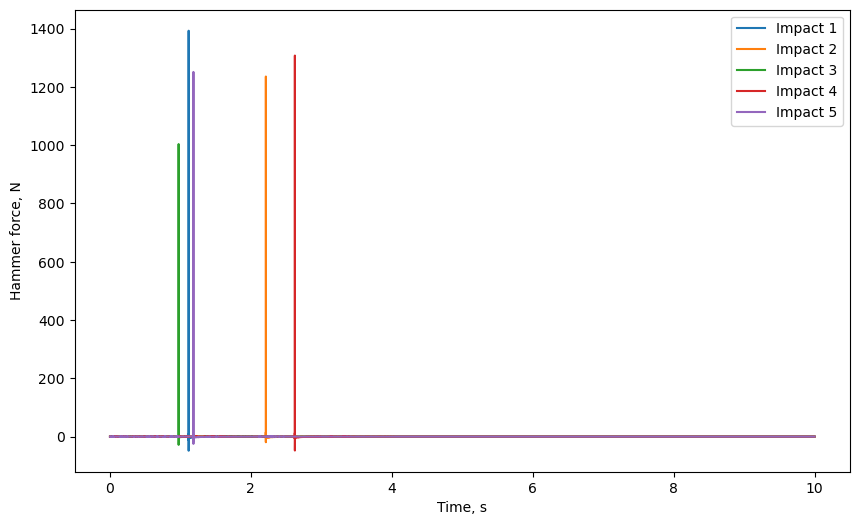

impact 1 is the largest with a maximum force of 1392.52 Nand impact 3 is the smallest with a maximum force of 1003.66 N


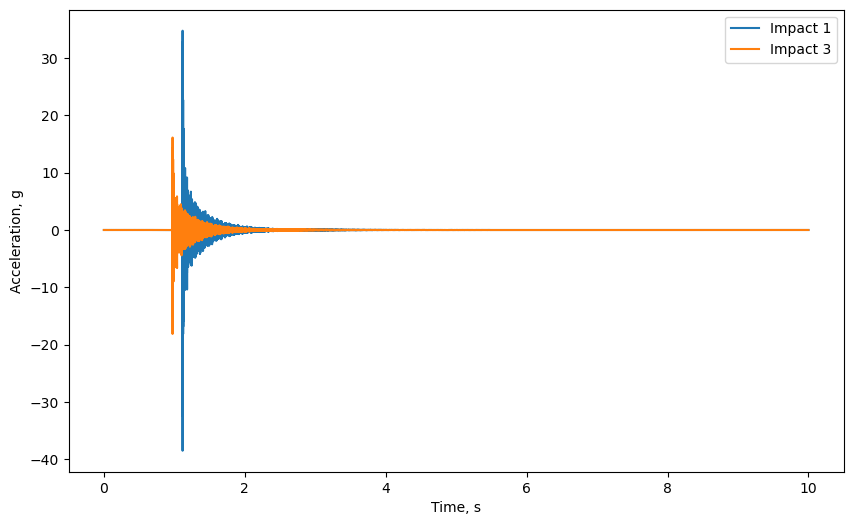

In [4]:

# Plot F_2 vs time for all 5 impacts
plt.figure(figsize=(10, 6))
for i in range(5):
    plt.plot(t_F2[:, i], F_2[:, i], label=f'Impact {i+1}')
plt.xlabel('Time, s')
plt.ylabel('Hammer force, N')
plt.legend()

plt.show()

# impact 3 is the smallest and impact 1 is the largest
print(
    f"impact 1 is the largest with a maximum force of {np.max(F_2[:, 0]):.2f} N"       
    f"and impact 3 is the smallest with a maximum force of {np.max(F_2[:, 2]):.2f} N"
      )
acc2 = np.column_stack([
    data_acc2T1[:, 5],
    data_acc2T2[:, 5],
    data_acc2T3[:, 5],
    data_acc2T4[:, 5],
    data_acc2T5[:, 5],
])
t_acc2 = np.column_stack([
    data_acc2T1[:, 4],
    data_acc2T2[:, 4],
    data_acc2T3[:, 4],
    data_acc2T4[:, 4],
    data_acc2T5[:, 4],
])

# Plot acc2 vs time for impact 1 and impact 3
plt.figure(figsize=(10, 6))
plt.plot(t_acc2[:, 0], acc2[:, 0], label='Impact 1')
plt.plot(t_acc2[:, 2], acc2[:, 2], label='Impact 3')
plt.xlabel('Time, s')
plt.ylabel('Acceleration, g')
plt.legend()

plt.show()


### Exercise 1.2. Fourier transform and power spectral density (PSD)
**a**. Plot the positive part of the double-sided Fourier amplitude spectrums of the five forces in one figure in log-log scale. Explain the similarities and differences between different force spectrums.

C:\Users\josej\AppData\Local\Temp\ipykernel_756\2167341004.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


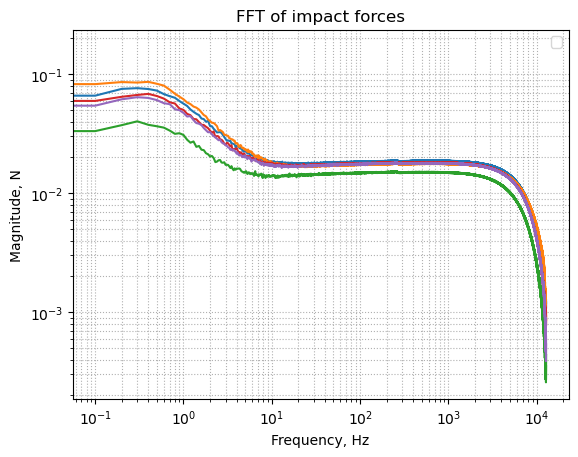

In [5]:


sf = 25600
N_sig = F_2.shape[0] # number of data points in the signal
freq = fftfreq(N_sig, 1/sf)[:N_sig//2] # fourier frequencies

# Calculate the fft of each force and plot them in one figure
plt.figure
for ii in range(5):
    fft_force = fft(F_2[:,ii],axis = -1)
    # plot the positive part of the fourier spectrum in log-log scale
    plt.loglog(freq, 2.0/N_sig * np.abs(fft_force[0:N_sig//2]))

# plt.xlim(10, 10000)
plt.xlabel('Frequency, Hz')
plt.ylabel('Magnitude, N')
plt.title('FFT of impact forces')
plt.legend()
plt.grid(True, which='both', ls=':')
plt.show()



**b**. List the first three natural frequencies calculated by the analytical model.

In [6]:
# Rail properties
E = 210e9          # Young's modulus [Pa]
rho = 7850         # Density [kg/m^3]
I = 2337.9e-8      # Moment of inertia [m^4]   (2337.9 cm^4 -> m^4)
A = 69.77e-4       # Cross-sectional area [m^2] (69.77 cm^2 -> m^2)

# Measured beam length
L = 3.0            # [m] replace with your measured beam length

# Free-free beam values: beta_n * L
betaL = np.array([4.730041, 7.853205, 10.995608])

# beta_n
beta = betaL / L

# Natural frequencies in rad/s
omega_n = (betaL**2) * np.sqrt(E * I / (rho * A * L**4))

# Natural frequencies in Hz
f_n = omega_n / (2 * np.pi)

print("Natural frequencies (rad/s):", omega_n)
print("Natural frequencies (Hz):", f_n)

for i, f in enumerate(f_n, start=1):
    print(f"Mode {i}: {f:.2f} Hz")


Natural frequencies (rad/s): [ 744.28749782 2051.65712316 4022.06801763]
Natural frequencies (Hz): [118.45703436 326.53137268 640.13200646]
Mode 1: 118.46 Hz
Mode 2: 326.53 Hz
Mode 3: 640.13 Hz


**c**. Calculate the Fourier transform of $a_{22,max}$ and $a_{22,min}$. Plot the positive part of the double-sided Fourier amplitude spectrums of the two accelerations in one figure in log-log scale. Please use `plt.xlim` to zoom in to the frequency range that shows the first three natural frequencies. Explain the similarities and differences between the two spectrums.

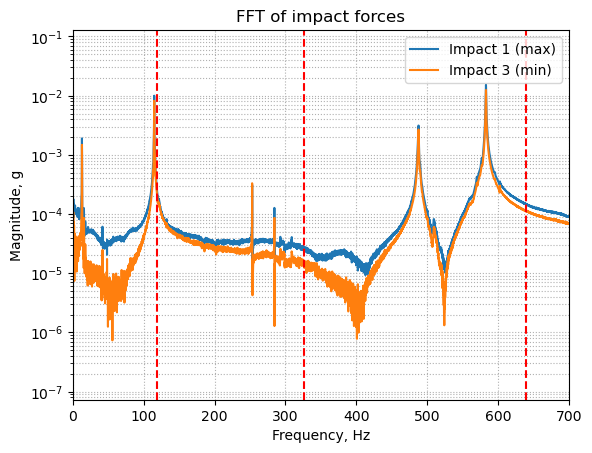

In [7]:
sf = 25600
N_sig = acc2.shape[0] # number of data points in the signal
freq = fftfreq(N_sig, 1/sf)[:N_sig//2] # fourier frequencies

# Calculate the fft of each force and plot them in one figure

fft_acc2 = []
for ii in range(5):
    fft_acc2.append(fft(acc2[:,ii],axis = -1))
    # plot the positive part of the fourier spectrum in log-log scale


plt.semilogy(freq, 2.0/N_sig * np.abs(fft_acc2[0][0:N_sig//2]), label='Impact 1 (max)')
plt.semilogy(freq, 2.0/N_sig * np.abs(fft_acc2[2][0:N_sig//2]), label='Impact 3 (min)')
plt.xlim(0, 700)

plt.xlabel('Frequency, Hz')
plt.ylabel('Magnitude, g')
plt.title('FFT of impact forces')
plt.legend()
plt.grid(True, which='both', ls=':')
# inlcude 3 natural frequencies in the plot
for f in f_n:
    plt.axvline(f, color='r', linestyle='--', label=f'Natural frequency: {f:.2f} Hz')
    

plt.show()

**d**. Calculate the Welch periodogram of the PSD of $a_{22,max}$. Plot the periodogram in log-log scale. 

- Please use `plt.xlim` to zoom in to the frequency range that shows the first three natural frequencies.

- Use a rectangular window with different lengths to see its effect. (set the argument `nperseg` with different values)

- Compare the Welch periodogram  and Fourier spectrum of $a_{22,max}$,and explain the main differences between the two.

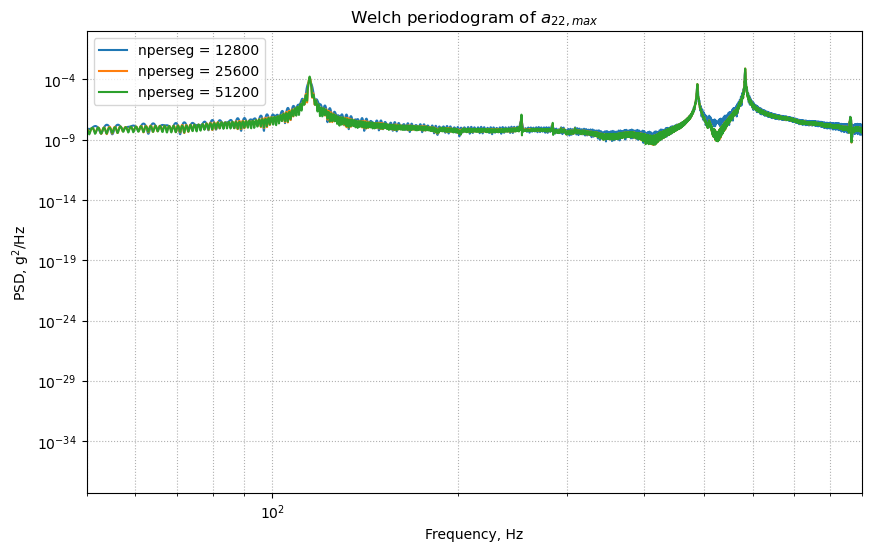

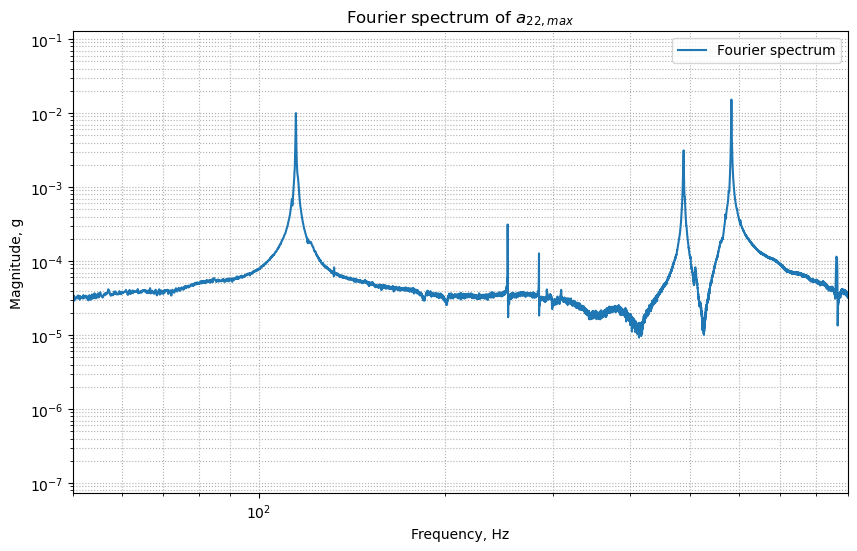

In [27]:
# a22,max from the impact with the largest peak force
peak_forces = np.max(F_2, axis=0)
max_idx = np.argmax(peak_forces)
a22_max = acc2[:, max_idx]

sf = 25600
N_sig = a22_max.shape[0]
N_fft = N_sig
N_overlap = 0

# Different rectangular window lengths
window_lengths = [N_sig // 20, N_sig // 10, N_sig // 5]

plt.figure(figsize=(10, 6))
for N_window in window_lengths:
    fxx, pxx = signal.welch(
        a22_max,
        sf,
        window='boxcar',
        nperseg=N_window,
        noverlap=N_overlap,
        nfft=N_fft
    )
    plt.loglog(fxx, pxx, label=f'nperseg = {N_window}')

plt.xlim(50, 900)   # adjust to show your first 3 natural frequencies
plt.xlabel('Frequency, Hz')
plt.ylabel('PSD, g$^2$/Hz')
plt.title(r'Welch periodogram of $a_{22,max}$')
plt.legend()
plt.grid(True, which='both', ls=':')
plt.show()

fft_acc = fft(a22_max)
freq = fftfreq(N_sig, 1 / sf)[:N_sig // 2]
amp_fft = 2.0 / N_sig * np.abs(fft_acc[:N_sig // 2])

plt.figure(figsize=(10, 6))
plt.loglog(freq[1:], amp_fft[1:], label='Fourier spectrum')
plt.xlim(50, 900)
plt.xlabel('Frequency, Hz')
plt.ylabel('Magnitude, g')
plt.title(r'Fourier spectrum of $a_{22,max}$')
plt.legend()
plt.grid(True, which='both', ls=':')
plt.show()


### Exercise 1.3. Signal alignment, windowing and zero-padding

**a. (Force window)** Choose one impact force, apply a force window, and plot the windowed and orginal signals in the same figure to show the differences.

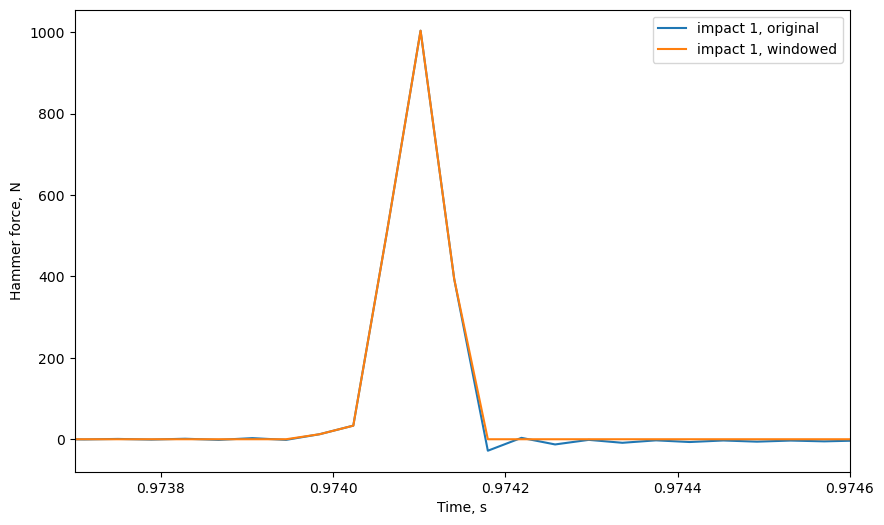

In [ ]:
# Choose one impact force
force_signal = F_2[:, 2]
time_signal = t_F2[:, 0]

# Define a trigger force
force_trigger = 5

# Get the boolean indices of the force larger than the trigger force
idx_boolean = force_signal > force_trigger

# Find the indices of triggered force
idx_triggered = np.where(idx_boolean)[0]

# Define a rectangular window
rec_win = np.zeros(len(force_signal))
rec_win[idx_triggered] = 1

# Apply the force window
f_windowed = np.multiply(force_signal, rec_win)

# Plot original and windowed force
plt.figure(figsize=(10, 6))
plt.plot(time_signal, force_signal, label='impact 1, original')
plt.plot(time_signal, f_windowed, label='impact 1, windowed')
plt.xlabel('Time, s')
plt.ylabel('Hammer force, N')
plt.xlim((0.9737, 0.9746))   # adjust to your impact
# plt.ylim((-40, 300))
# plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(0.00015))
plt.legend()
plt.show()


**b. (Signal alignment)** In Exercise 1.1.c, we showed that the forces and accelerations for different impacts are not aligned in the time domain. To align the signals, you can truncate each force signal from a few (e.g., 10) samples before the index of the first triggered force. Show the aligned force and acceleration sigals.Please use $F_{2,max}$ ($a_{22,max}$) and $F_{2,min}$ ($a_{22,min}$) as examples.

In [10]:
# Your answer

**c. (Exponential window)**. Apply an exponential window to aligned $a_{22,max}$.The exponential window can be calculated as $w(t)=e^{(-\beta t)}$. Compare the windowed and orignal signals with different $\beta$ values. Explain why an exponential window is necessry and what its effect for the modal analysis later on.

In [11]:
# Your answer

**d. (Zero-padding)** Caculate the Welch periodogram of the windowed $a_{22,max}$.This time zero-pad the signal to 40 seconds by setting the `nfft` argument in `signal.welch` to the correct value. Please use `plt.xlim` to zoom in to the frequency range that shows the first three natural frequencies. Compare this periodogram with the one in Exercise 1.2.d. What are the main differences and why?

In [12]:
# Your answer

# Problem set 2: frequency response functions (FRF)

###  Exercise 2.1. H1 estimator of FRF

**a**. Plot the processed input (force) signal and output (acceleration) signal.

In [13]:
# Your answer

**b**. Calculate the PSD, CSD and H1 estimator of the FRF ($\hat{H}_{22}(\omega)$) using the processed input (force) signals and output (acceleration) signals.Plot the amplitude and phase angle of ($\hat{H}_{22}(\omega)$).

In [14]:
# Your answer

### Exercise 2.2. FRF matrix
**a.** How many FRFs can you obtain from the data collected in Lab Session 1? Which are the driving-point FRFs and which are the transfer FRFs?

In [15]:
# Your answer

**b**. For the hammer impact at position 1, caluclate the plot the driving-point FRF $\hat{H}_{11}(\omega)$ and one tranfer FRF of your choice. Explain

- The main differences between $\hat{H}_{11}(\omega)$ and $\hat{H}_{22}(\omega)$, and

- The main differences between the driving-point and transfer FRFs

In [16]:
# Your answer

# Problem set 3: Modal parameter identification and statistic model updating.


### Exercise 3.1. Natural frequencies and damping ratio

**a**. Use a figure to show the $N$ measurement positions. Calculate the $N$ FRFs and plot them in one figure.

In [17]:
# Your answer

**b**. Identify the first three natural frequencies of the beam bending modes from one of the FRFs you showed in Exercise 3.1.a (choose one as you wish). Compare the first three natural frequencies obtained from the FRF with those calculated from the analytical model (Exercise 1.2.b) and discuss what the possilbe causes for the discrepencies are.

In [18]:
# Your answer

**c**. Estimate the damping ratio of the first three natural frequencies using the same FRF as in Exercise 3.1.b. For this, you can use the half-power bandwidth method.

In [19]:
# Your answer

### Exercise 3.2. Mode shapes

**a.** Plot the modal amplitude $a_1$ at the $N$ positions to show the first mode shape. Note that you should scale the modal amplitude $a_1$ so that its maximum amplitude is 100.

In [20]:
# Your answer

**b.** Calculate and show the first three analytical mode shapes of a free-free beam. Note that you should scale each mode shape $W_n(x)$ so that its maximum amplitude is 100.

In [21]:
# Your answer

**c.** Plot the measured (Exercise 3.2.a) and analytical (Exercise 3.2.b) model shapes for the first mode in one figure. Caculate the Modal Assurance Criterion (MAC) value between the two mode shapes. Explain what this MAC value indicates.

In [22]:
# Your answer

### Exercise 3.3. Analysis of measurement uncertainty （optional）

Compare the FRFs measured with hits at ideal and deviated locations and analyze how the hammer hitting positions may influence the measurement results.

In [23]:
# Your answer